In [94]:
import wandb
import transformers
import torch
import pandas as pd
import os, glob, re, random
from skimage.metrics import peak_signal_noise_ratio as psnr
from sklearn.decomposition import PCA
from transformers import pipeline
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.cm as cm
import os, glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import math
from pathlib import Path

In [95]:
wandb.login()

True

In [96]:
api = wandb.Api()

In [97]:
def plot_wandb_images_grid(
    run,
    metric: str,
    *,
    title: str = "",
    label: str = "",
    max_images: int = 16,
    samples: int = 2000,
    unique: bool = True,
    show_steps: bool = True,
    step_key: str = "_step",
    download_dir: str = "./wandb_media_cache",
):
    df = run.history(samples=samples)
    if df is None or df.empty:
        raise ValueError("run.history() is empty.")

    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not found in history columns.")

    cols = [metric] + ([step_key] if (show_steps and step_key in df.columns) else [])
    d = df[cols].dropna(subset=[metric]).copy()
    if d.empty:
        raise ValueError(f"No logged images found for '{metric}' after dropna.")

    cache_root = Path(download_dir)
    cache_root.mkdir(parents=True, exist_ok=True)

    def _extract_path_or_url(obj):
        if isinstance(obj, dict):
            return obj.get("path"), obj.get("url")
        if hasattr(obj, "path"):
            return getattr(obj, "path"), None
        if hasattr(obj, "_path"):
            return getattr(obj, "_path"), None
        if isinstance(obj, str):
            if obj.startswith("http"):
                return None, obj
            return obj, None
        return None, None

    def _load_image(obj):
        path, url = _extract_path_or_url(obj)

        if hasattr(obj, "image") and obj.image is not None:
            return np.array(obj.image)

        if url:
            raise ValueError(
                "URL detected, but URL downloading is disabled here. Use path/Run files instead."
            )

        if path:
            local_path = cache_root / path
            local_path.parent.mkdir(parents=True, exist_ok=True)

            if not local_path.exists():
                try:
                    run.file(path).download(root=str(cache_root), replace=True)
                except Exception as e:
                    raise ValueError(
                        f"Download via run.file('{path}') failed: {e}"
                    )

            if not local_path.exists():
                raise ValueError(
                    f"Download seemed successful, but file not found: {local_path}"
                )

            img = plt.imread(str(local_path))
            return img

        raise ValueError(f"No path/url found in object (type={type(obj)})")

    items = []
    seen = set()

    for _, row in d.iterrows():
        obj = row[metric]
        step = row[step_key] if (show_steps and step_key in row) else None

        path, url = _extract_path_or_url(obj)
        key = url or path or repr(obj)

        if unique and key in seen:
            continue
        seen.add(key)

        items.append((obj, step))
        if len(items) >= max_images:
            break

    if not items:
        raise ValueError("No images left after deduplication/limit.")

    n = len(items)
    k = math.ceil(math.sqrt(n))

    fig, axes = plt.subplots(k, k, figsize=(3.5 * k, 3.5 * k))
    axes = np.array(axes).reshape(-1)

    header = title or metric
    if label:
        header = f"{header} — {label}"
    fig.suptitle(header)

    for i, (obj, step) in enumerate(items):
        ax = axes[i]
        ax.axis("off")
        try:
            img = _load_image(obj)
            ax.imshow(img)
            if show_steps and step is not None:
                try:
                    ax.set_title(f"step={int(step)}", fontsize=10)
                except Exception:
                    ax.set_title(f"step={step}", fontsize=10)
        except Exception as e:
            ax.text(0.5, 0.5, f"Load error:\n{e}", ha="center", va="center")
            ax.axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


In [98]:
def plot_wandb_single_image_at_step(
    run,
    *,
    metric: str,
    step: int,
    title: str = "",
    label: str = "",
    step_key: str = "_step",
    samples: int = 10000,
    download_dir: str = "./wandb_media_cache",
    figsize=(6, 6),
):
    df = run.history(samples=samples)

    if df is None or df.empty:
        raise ValueError("run.history() is empty.")

    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not found in history columns.")

    if step_key not in df.columns:
        raise ValueError(f"step_key '{step_key}' not found in history columns.")

    d = df[df[step_key] == step]
    if d.empty:
        raise ValueError(f"No entry found for step={step}.")

    row = d.tail(1).iloc[0]
    obj = row[metric]

    if pd.isna(obj):
        raise ValueError(f"Metric '{metric}' is NaN at step={step}.")

    cache_root = Path(download_dir)
    cache_root.mkdir(parents=True, exist_ok=True)

    def _extract_path_or_url(obj):
        if isinstance(obj, dict):
            return obj.get("path"), obj.get("url")
        if hasattr(obj, "path"):
            return getattr(obj, "path"), None
        if hasattr(obj, "_path"):
            return getattr(obj, "_path"), None
        if isinstance(obj, str):
            if obj.startswith("http"):
                return None, obj
            return obj, None
        return None, None

    def _load_image(obj):
        if hasattr(obj, "image") and obj.image is not None:
            return np.array(obj.image)

        path, url = _extract_path_or_url(obj)

        if url:
            raise ValueError(
                "URL detected, but URL downloading is not implemented."
            )

        if path:
            local_path = cache_root / path
            local_path.parent.mkdir(parents=True, exist_ok=True)

            if not local_path.exists():
                run.file(path).download(root=str(cache_root), replace=True)

            if not local_path.exists():
                raise ValueError(
                    f"File not found after download: {local_path}"
                )

            return plt.imread(str(local_path))

        raise ValueError(f"No path/url found in object (type={type(obj)})")

    img = _load_image(obj)

    plt.figure(figsize=figsize)

    header = title or metric
    if label:
        header = f"{header} — {label}"
    header = f"{header} (step={step})"

    plt.title(header)
    plt.axis("off")
    plt.imshow(img)
    plt.tight_layout()
    plt.show()


In [99]:
def plot_wandb_metric_compare_runs_plus_mean(
    runs_a,
    runs_b,
    *,
    metric: str,
    title: str,
    xlabel: str,
    ylabel: str,
    label_a: str,
    label_b: str,
    x_key: str = "_step",
    samples: int = 5000,
    smooth_window: int | None = None,
    show_std: bool = True,
    alpha_runs: float = 0.25,
    alpha_band: float = 0.18,
    lw_runs: float = 1.0,
    lw_mean: float = 3.5,
    debug: bool = False,
):
    def get_series(run):
        df = run.history(samples=samples)
        if df is None or df.empty:
            if debug:
                print(f"[skip] {run.name}: history is empty")
            return None

        if x_key not in df.columns or metric not in df.columns:
            if debug:
                print(f"[skip] {run.name}: missing required columns")
            return None

        d = df[[x_key, metric]].dropna()
        d[x_key] = pd.to_numeric(d[x_key], errors="coerce")
        d[metric] = pd.to_numeric(d[metric], errors="coerce")
        d = d.dropna().sort_values(x_key)

        if len(d) <= 1:
            if debug:
                print(f"[skip] {run.name}: too few points")
            return None

        s = d.set_index(x_key)[metric]
        s = s[~s.index.duplicated(keep="last")]
        if len(s) <= 1:
            if debug:
                print(f"[skip] {run.name}: too few unique steps")
            return None

        if debug:
            print(f"[ok] {run.name}: {len(s)} points")
        return s

    def build_group(runs):
        series_list = []
        for r in runs:
            s = get_series(r)
            if s is not None:
                series_list.append(s)

        if not series_list:
            return None, None, None

        x_all = np.array(sorted(set().union(*[s.index.to_numpy() for s in series_list])))
        x_all = x_all[~np.isnan(x_all)]
        if x_all.size == 0:
            return None, None, None

        mat = []
        for s in series_list:
            y = s.reindex(x_all).interpolate(method="index", limit_direction="both")
            mat.append(y.to_numpy())

        M = np.vstack(mat)
        return x_all, M, series_list

    def smooth(y):
        if smooth_window is None or smooth_window <= 1:
            return y
        return (
            pd.Series(y)
            .rolling(smooth_window, center=True, min_periods=1)
            .mean()
            .to_numpy()
        )

    def plot_group(x, M, series_list, *, color, label):
        for s in series_list:
            plt.plot(
                s.index,
                s.values,
                color=color,
                linewidth=lw_runs,
                alpha=alpha_runs,
            )

        mean = smooth(np.nanmean(M, axis=0))
        std = np.nanstd(M, axis=0)

        plt.plot(
            x,
            mean,
            color=color,
            linewidth=lw_mean,
            label=f"{label} (mean, n={M.shape[0]})",
        )

        if show_std:
            plt.fill_between(
                x,
                mean - std,
                mean + std,
                color=color,
                alpha=alpha_band,
                linewidth=0,
            )

    x_a, M_a, series_a = build_group(runs_a)
    x_b, M_b, series_b = build_group(runs_b)

    plt.figure()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plotted = False

    if M_a is not None:
        plot_group(x_a, M_a, series_a, color="C0", label=label_a)
        plotted = True

    if M_b is not None:
        plot_group(x_b, M_b, series_b, color="C1", label=label_b)
        plotted = True

    if not plotted:
        raise ValueError(
            f"No plottable data found. Check metric='{metric}' and x_key='{x_key}'."
        )

    plt.legend()
    plt.tight_layout()
    plt.show()


In [100]:
def plot_wandb_images_triplet_by_index(
    run,
    metrics,
    *,
    title: str = "",
    labels=None,
    step_key: str = "_step",
    samples: int = 5000,
    max_rows: int = 9,
    start: int = 0,
    unique: bool = True,
    download_dir: str = "./wandb_media_cache",
    figsize_per_cell=(4.0, 4.0),
    show_step: bool = False,
    strict_equal_lengths: bool = False,
):
    if not isinstance(metrics, (list, tuple)) or len(metrics) != 3:
        raise ValueError("metrics must be a list/tuple with exactly 3 entries.")
    if labels is None:
        labels = list(metrics)
    if not isinstance(labels, (list, tuple)) or len(labels) != 3:
        raise ValueError("labels must be None or a list/tuple with exactly 3 entries.")

    df = run.history(samples=samples)
    if df is None or df.empty:
        raise ValueError("run.history() is empty.")

    missing = [c for c in metrics if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in history: {missing}")

    cache_root = Path(download_dir)
    cache_root.mkdir(parents=True, exist_ok=True)

    def _extract_path_or_url(obj):
        if isinstance(obj, dict):
            return obj.get("path"), obj.get("url")
        if hasattr(obj, "path"):
            return getattr(obj, "path"), None
        if hasattr(obj, "_path"):
            return getattr(obj, "_path"), None
        if isinstance(obj, str):
            if obj.startswith("http"):
                return None, obj
            return obj, None
        return None, None

    def _load_image(obj):
        if hasattr(obj, "image") and obj.image is not None:
            return np.array(obj.image)

        path, url = _extract_path_or_url(obj)

        if url:
            raise ValueError(
                "URL detected, but URL downloading is disabled. Use W&B path/run.file() instead."
            )

        if path:
            local_path = cache_root / path
            local_path.parent.mkdir(parents=True, exist_ok=True)

            if not local_path.exists():
                run.file(path).download(root=str(cache_root), replace=True)

            if not local_path.exists():
                raise ValueError(f"File not found after download: {local_path}")

            return plt.imread(str(local_path))

        raise ValueError(f"No path/url found in object (type={type(obj)})")

    sequences = []
    for m in metrics:
        s = []
        seen = set()

        d = df[[m] + ([step_key] if step_key in df.columns else [])].copy()
        d = d.dropna(subset=[m])
        if d.empty:
            sequences.append([])
            continue

        if step_key in d.columns:
            d = d.sort_values(step_key)

        for _, row in d.iterrows():
            obj = row[m]
            step = row[step_key] if (step_key in d.columns) else None

            path, url = _extract_path_or_url(obj)
            key = url or path or repr(obj)

            if unique and key in seen:
                continue
            seen.add(key)

            s.append((obj, step, key))

        sequences.append(s)

    lens = [len(s) for s in sequences]
    if strict_equal_lengths and len(set(lens)) != 1:
        raise ValueError(f"Image sequence lengths differ: {lens}")

    n_total = min(lens) if min(lens) > 0 else 0
    if n_total == 0:
        raise ValueError(f"No images found. Sequence lengths: {lens}")

    end = min(n_total, start + max_rows)
    if start >= end:
        raise ValueError(f"start={start} is too large. Available: 0..{n_total - 1}")

    n_rows = end - start
    n_cols = 3

    fig_w = figsize_per_cell[0] * n_cols
    fig_h = figsize_per_cell[1] * n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))

    if n_rows == 1:
        axes = np.array([axes])

    header = title or " | ".join(metrics)
    fig.suptitle(f"{header}\n", y=1.01)

    for c in range(n_cols):
        axes[0, c].set_title(str(labels[c]), fontsize=12)

    for i in range(n_rows):
        idx = start + i
        for c, _m in enumerate(metrics):
            ax = axes[i, c]
            ax.axis("off")

            obj, step, _ = sequences[c][idx]
            try:
                img = _load_image(obj)
                ax.imshow(img)
                if show_step and step is not None:
                    ax.text(
                        0.01,
                        0.99,
                        f"step={step}",
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        fontsize=10,
                        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"),
                    )
            except Exception as e:
                ax.text(0.5, 0.5, f"Load error:\n{e}", ha="center", va="center")

        axes[i, 0].text(
            -0.02,
            0.5,
            f"idx={idx}",
            transform=axes[i, 0].transAxes,
            ha="right",
            va="center",
            fontsize=11,
        )

    plt.tight_layout()
    plt.show()


In [101]:
import wandb

api = wandb.Api()
entity = "vton_pipeline"
project = "vton_optical_flow"

runs = api.runs(f"{entity}/{project}")

optical_flow_runs = []
no_optical_flow_runs = []

for r in runs:
    name = (r.name or "").lower()

    if "no_opflow" in name:
        no_optical_flow_runs.append(r)
    elif "opflow" in name:
        optical_flow_runs.append(r)

print("optical_flow:", len(optical_flow_runs))
print("no_optical_flow:", len(no_optical_flow_runs))


optical_flow: 9
no_optical_flow: 9


In [ ]:
r = optical_flow_runs[0]

df = r.history(samples=2000)
print(df.columns.tolist())


In [ ]:

r = optical_flow_runs[2]

plot_wandb_images_triplet_by_index(
    r,
    metrics=["qwen/input_image", "opticalflow/aligned", "opticalflow/heatmap_diff"],
    labels=["img0", "img1", "img2"],
    title="GSplat Val Images",
    max_rows=30,
    start=0,
    samples=8000,
    download_dir="./wandb_media_cache",
)


Here some Images where the optical flow alignment worked really well. The first column is the input image, the second column is the aligned image using optical flow, and the third column is the heatmap of the difference between the aligned image and the ground truth, where the generated Clothing is maksed because it is of course different from the GT. The heatmap is of course everywhere 0 because whe masked the generated Clothing and changed all other Pixels to the Input Image. But in the aligned image it is visible that it looks realistic and not shifted between the clothing from qwen and the other pixels from input image which shows us that the optical flow alignment worked well.

In [ ]:
r = optical_flow_runs[1]

plot_wandb_images_triplet_by_index(
    r,
    metrics=["qwen/input_image", "opticalflow/aligned", "opticalflow/heatmap_diff"],
    labels=["img0", "img1", "img2"],
    title="GSplat Val Images",
    max_rows=30,
    start=0,
    samples=8000,
    download_dir="./wandb_media_cache",
)


Here is an example where the optical flow alignment did not work perfectly. The problem is, that Qwen generated also the shirt new and not only the pants. This means that the masking has some pixels of the new generated shirt (blue stripe at shirt bottom) It is not a very bad error, but it can have some influence on the 3D Reconstruction.

In [ ]:
r = optical_flow_runs[0]

plot_wandb_images_grid(
    r,
    metric="gsplat_val/image_1",
    title="gsplat_val/image_0",
    label="optical_flow",
    max_images=30,
    samples=5000,
    show_steps=True,
    download_dir="./wandb_media_cache",
)


In [ ]:
r = no_optical_flow_runs[0]
plot_wandb_images_grid(
    r,
    metric="gsplat_val/image_1",
    title="gsplat_val/image_0",
    label="no_optical_flow",
    max_images=30,
    samples=5000,
    show_steps=True,
    download_dir="./wandb_media_cache",
)

Here we can see that the reconstructions with optical flow alignment look much more stable and less blurry than the ones without optical flow. This is a strong indication that the optical flow alignment is working well and helps to improve the quality of the reconstruction.

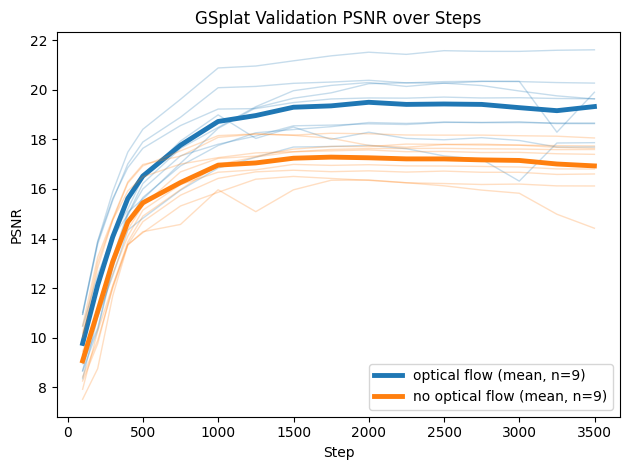

In [102]:
plot_wandb_metric_compare_runs_plus_mean(
    optical_flow_runs,
    no_optical_flow_runs,
    metric="gsplat_val/psnr",
    title="GSplat Validation PSNR over Steps",
    xlabel="Step",
    ylabel="PSNR",
    label_a="optical flow",
    label_b="no optical flow",
    x_key="_step",
    show_std=False,
    samples=5000,
    debug=False,
)


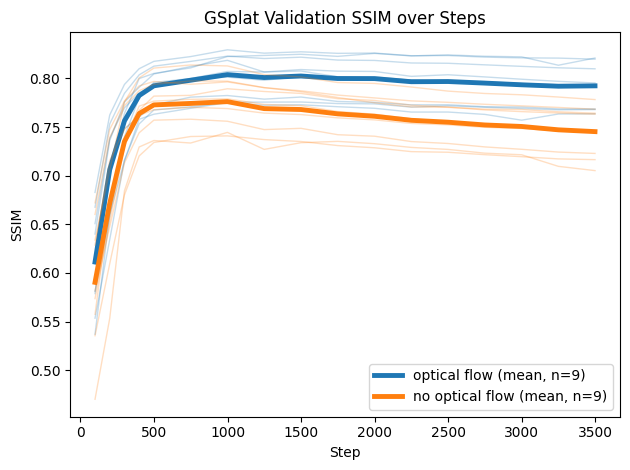

In [103]:
plot_wandb_metric_compare_runs_plus_mean(
    optical_flow_runs,
    no_optical_flow_runs,
    metric="gsplat_val/ssim",
    title="GSplat Validation SSIM over Steps",
    xlabel="Step",
    ylabel="SSIM",
    label_a="optical flow",
    label_b="no optical flow",
    x_key="_step",
    show_std=False,
    samples=5000,
    debug=False,
)


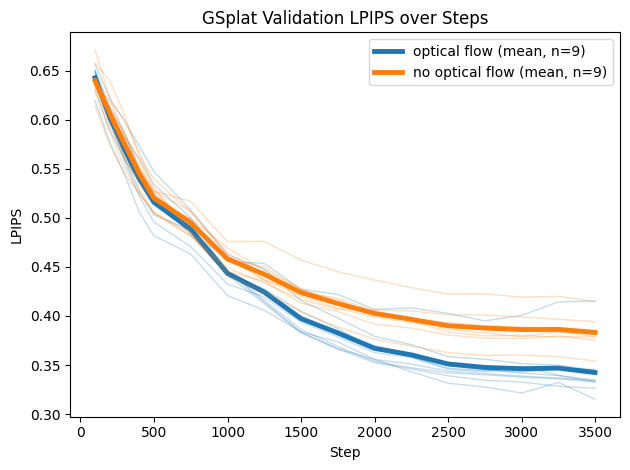

In [104]:
plot_wandb_metric_compare_runs_plus_mean(
    optical_flow_runs,
    no_optical_flow_runs,
    metric="gsplat_val/lpips",
    title="GSplat Validation LPIPS over Steps",
    xlabel="Step",
    ylabel="LPIPS",
    label_a="optical flow",
    label_b="no optical flow",
    x_key="_step",
    show_std=False,
    samples=5000,
    debug=False,
)


Also in the gaussian splatting validation metrics it is clearkly visible that the runs with optical flow alignment have a much better performance than the ones without optical flow. This is a strong evidence that the optical flow alignment is really helping to improve the quality of the reconstruction and the final results.